# 03. Machine Learning Modeling

## 문화시설 활성화에 대한 운영·이용 현황 성과 분석

이 노트북은 EDA와 통계분석 결과를 바탕으로 **관람객 수 예측 모델**을 구성하고 비교하는 단계이다.

- 목적변수: `LOG1P_VIEWNG_NMPR_CO`
- 예측 대상: 로그 변환 관람객 수
- 주요 비교:
  - 기본 변수 세트
  - 자료·규모 확장 변수 세트
  - 인력 변수 포함 실험 변수 세트
- 주요 모델:
  - Dummy Regressor
  - Linear Regression
  - Ridge / Lasso
  - Random Forest
  - Extra Trees
  - Gradient Boosting

## 0. 분석 방향

이번 머신러닝 단계의 핵심은 단순히 예측 성능이 가장 높은 모델을 찾는 것이 아니라,  
**어떤 운영·시설 요인이 관람객 수 예측에 기여하는지**를 확인하는 것이다.

따라서 아래 관점으로 진행한다.

1. 평균 예측 모델 대비 실제 입력 변수를 사용한 모델이 얼마나 개선되는가?
2. 기본 변수만으로 어느 정도 설명이 가능한가?
3. 자료·규모 변수와 인력 변수를 추가했을 때 성능이 개선되는가?
4. 최종 모델에서 중요한 변수는 무엇인가?
5. 실제 관람객 수 기준으로 예측 오차는 어느 정도인가?

In [1]:
# 필요 라이브러리 불러오기

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
)

from sklearn.inspection import permutation_importance
from sklearn.base import clone

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 불러오기

프로젝트 폴더 기준으로 아래 경로의 전처리 완료 데이터를 사용한다.

```text
data/processed/facility_eda_preprocessed.csv
```

다른 위치에서 실행할 경우를 대비해 몇 개의 후보 경로를 함께 확인한다.

In [2]:
# 데이터 경로 설정

path_candidates = [
    "data/processed/facility_eda_preprocessed.csv",
    "../data/processed/facility_eda_preprocessed.csv",
    "./facility_eda_preprocessed.csv",
    "/mnt/data/facility_eda_preprocessed.csv",  # ChatGPT 실행 검증용
]

data_path = None

for path in path_candidates:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "facility_eda_preprocessed.csv 파일을 찾지 못했습니다. "
        "data/processed/facility_eda_preprocessed.csv 경로를 확인해주세요."
    )

df = pd.read_csv(data_path)

print(f"데이터 경로: {data_path}")
print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]:,}열")

df.head()

데이터 경로: data/processed/facility_eda_preprocessed.csv
데이터 크기: 1,191행 × 64열


,facility_type,ID,FCLTY_NM,CTPRVN_NM,SIGNGU_NM,LEGALDONG_NM,ADSTRD_NM,FCLTY_LO,FCLTY_LA,OPNNG_DE,OPNNG_DE_RAW,OPNNG_DE_PRECISION,OPNNG_DAY_CO,BASE_DE,LAST_CHG_DE,LND_AR_VALUE,EDC_FCLTY_AR_VALUE,DATA_SPCE_AR_VALUE,NMPR_CO,QUALF_HOLD_CO,GNRL_GVRNM_EMP_CO,CNTRCT_EMP_CO,PUBLIC_VLNTER_CO,ARTGR_EMP_CO,PRFSN_CO,PRVATE_VLNTER_CO,DATA_CO,TOT_PROGRM_CO,VIEWNG_NMPR_CO,DAY_AVRG_VIEWNG_NMPR_CO,MOBILE_PROVD_AT,SOUND_PROVD_AT,HMPG_ADDR,TEL_NO,OPNNG_DAY_CO_IQR_OUTLIER,LND_AR_VALUE_IQR_OUTLIER,EDC_FCLTY_AR_VALUE_IQR_OUTLIER,DATA_SPCE_AR_VALUE_IQR_OUTLIER,NMPR_CO_IQR_OUTLIER,QUALF_HOLD_CO_IQR_OUTLIER,GNRL_GVRNM_EMP_CO_IQR_OUTLIER,CNTRCT_EMP_CO_IQR_OUTLIER,PUBLIC_VLNTER_CO_IQR_OUTLIER,ARTGR_EMP_CO_IQR_OUTLIER,PRFSN_CO_IQR_OUTLIER,PRVATE_VLNTER_CO_IQR_OUTLIER,DATA_CO_IQR_OUTLIER,TOT_PROGRM_CO_IQR_OUTLIER,VIEWNG_NMPR_CO_IQR_OUTLIER,DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER,IQR_OUTLIER_FLAG_COUNT,OPNNG_YEAR,BASE_YEAR,OPERATING_YEARS,REGION_GROUP,SIDO_SIGUNGU,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_NMPR_CO,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO,LOG1P_DAY_AVRG_VIEWNG_NMPR_CO
0,박물관,KCDMMUS23N000000001,국립중앙박물관,서울,용산구,용산동6가,한강로동,126.977740,37.524702,1945-12-03,1945.12.03,day,360.0,2025-03-27,2025-03-27,285991.00,4975.00,1552.0,89.0,5.0,128.0,NaN,213.0,NaN,NaN,NaN,157323.0,16.0,4180285.0,11612.0,O,O,www.museum.go.kr,02-2077-9000,False,True,True,True,True,True,True,NaN,True,NaN,NaN,NaN,True,False,True,True,10,1945,2025,80,수도권,서울 용산구,12.563719,8.512382,7.347944,4.499810,11.966063,2.833213,15.245890,9.359880
1,박물관,KCDMMUS23N000000002,국립민속박물관,서울,종로구,세종로,청운효자동,126.978890,37.581675,1946-04-25,1946.04.25,day,362.0,2025-03-27,2025-03-27,39626.62,1376.68,324.0,58.0,1.0,37.0,8.0,81.0,NaN,NaN,NaN,92786.0,70.0,1307690.0,3612.0,O,X,www.nfm.go.kr,02-3704-3114,False,False,True,True,True,False,True,False,False,NaN,NaN,NaN,True,True,True,True,8,1946,2025,79,수도권,서울 종로구,10.587282,7.228156,5.783825,4.077537,11.438062,4.262680,14.083774,8.192294
2,박물관,KCDMMUS23N000000003,국립민속박물관 파주\n(개방형 수장고 및 정보센터),경기,파주시,탄현면 법흥리,탄현면,126.693918,37.786670,2021-07-23,2021.07.23,day,313.0,2025-03-27,2025-03-27,60212.70,277.49,NaN,NaN,NaN,NaN,NaN,37.0,NaN,NaN,NaN,NaN,10.0,83306.0,266.0,X,X,www.nfm.go.kr,031-580-5800,False,True,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False,False,False,1,2021,2025,4,수도권,경기 파주시,11.005655,5.629382,NaN,NaN,NaN,2.397895,11.330288,5.587249
3,박물관,KCDMMUS23N000000004,대한민국역사박물관,서울,종로구,세종로,종로1.2.3.4가동,126.978339,37.573714,2012-12-26,2012.12.26,day,362.0,2025-03-27,2025-03-27,6445.00,496.00,81.0,55.0,23.0,NaN,4.0,54.0,NaN,NaN,NaN,18065.0,34.0,788347.0,2178.0,O,O,www.much.go.kr,02-3703-9200,False,False,False,False,True,True,NaN,False,False,NaN,NaN,NaN,False,True,True,True,5,2012,2025,13,수도권,서울 종로구,8.771215,6.208590,4.406719,4.025352,9.801787,3.555348,13.577695,7.686621
4,박물관,KCDMMUS23N000000005,국립한글박물관,서울,용산구,용산동6가,서빙고동,126.980486,37.521069,2014-10-09,2014.10.09,day,362.0,2025-03-27,2025-03-27,285991.00,378.00,220.0,33.0,NaN,19.0,13.0,64.0,NaN,NaN,NaN,30059.0,33.0,397107.0,1097.0,O,O,www.hangeul.go.kr,02-2124-6200,False,True,False,True,True,NaN,True,True,False,NaN,NaN,NaN,True,True,True,True,9,2014,2025,11,수도권,서울 용산구,12.563719,5.937536,5.398163,3.526361,10.310951,3.526361,12.891964,7.001246


In [3]:
# 기본 정보 확인

print(df.info())

display(
    df[["facility_type", "CTPRVN_NM", "REGION_GROUP", "VIEWNG_NMPR_CO", "LOG1P_VIEWNG_NMPR_CO"]]
    .head()
)

<class 'pandas.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 64 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   facility_type                        1191 non-null   str    
 1   ID                                   1191 non-null   str    
 2   FCLTY_NM                             1191 non-null   str    
 3   CTPRVN_NM                            1191 non-null   str    
 4   SIGNGU_NM                            1191 non-null   str    
 5   LEGALDONG_NM                         1191 non-null   str    
 6   ADSTRD_NM                            1191 non-null   str    
 7   FCLTY_LO                             1191 non-null   float64
 8   FCLTY_LA                             1191 non-null   float64
 9   OPNNG_DE                             1191 non-null   str    
 10  OPNNG_DE_RAW                         1191 non-null   str    
 11  OPNNG_DE_PRECISION                   1191

,facility_type,CTPRVN_NM,REGION_GROUP,VIEWNG_NMPR_CO,LOG1P_VIEWNG_NMPR_CO
0,박물관,서울,수도권,4180285.0,15.245890
1,박물관,서울,수도권,1307690.0,14.083774
2,박물관,경기,수도권,83306.0,11.330288
3,박물관,서울,수도권,788347.0,13.577695
4,박물관,서울,수도권,397107.0,12.891964


## 2. 목적변수와 입력 변수 세트 정의

EDA와 통계분석 결과를 바탕으로 목적변수는 `LOG1P_VIEWNG_NMPR_CO`로 설정한다.

관람객 수 예측에서 아래 변수들은 데이터 누수 가능성이 있어 입력 변수에서 제외한다.

- `VIEWNG_NMPR_CO`
- `LOG1P_VIEWNG_NMPR_CO`
- `DAY_AVRG_VIEWNG_NMPR_CO`
- `LOG1P_DAY_AVRG_VIEWNG_NMPR_CO`
- `VIEWNG_NMPR_CO_IQR_OUTLIER`
- `DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER`
- `IQR_OUTLIER_FLAG_COUNT`

In [4]:
target = "LOG1P_VIEWNG_NMPR_CO"

leakage_cols = [
    "VIEWNG_NMPR_CO",
    "LOG1P_VIEWNG_NMPR_CO",
    "DAY_AVRG_VIEWNG_NMPR_CO",
    "LOG1P_DAY_AVRG_VIEWNG_NMPR_CO",
    "VIEWNG_NMPR_CO_IQR_OUTLIER",
    "DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER",
    "IQR_OUTLIER_FLAG_COUNT",
]

# 기본 변수 세트
features_basic = [
    "facility_type",
    "CTPRVN_NM",
    "OPERATING_YEARS",
    "OPNNG_DAY_CO",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_TOT_PROGRM_CO",
    "MOBILE_PROVD_AT",
    "SOUND_PROVD_AT",
]

# 자료·규모 확장 변수 세트
features_extended = features_basic + [
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_DATA_CO",
    "LOG1P_NMPR_CO",
]

# 인력 변수 포함 실험 변수 세트
features_staff = features_extended + [
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "GNRL_GVRNM_EMP_CO",
    "CNTRCT_EMP_CO",
    "PRFSN_CO",
    "PUBLIC_VLNTER_CO",
    "PRVATE_VLNTER_CO",
]

feature_sets = {
    "basic": features_basic,
    "extended": features_extended,
    "staff": features_staff,
}

for name, features in feature_sets.items():
    missing_features = [col for col in features if col not in df.columns]
    leakage_features = [col for col in features if col in leakage_cols]

    print(f"[{name}] 변수 수: {len(features)}")
    print("  - 누락 변수:", missing_features if missing_features else "없음")
    print("  - 누수 위험 변수:", leakage_features if leakage_features else "없음")

[basic] 변수 수: 9
  - 누락 변수: 없음
  - 누수 위험 변수: 없음
[extended] 변수 수: 12
  - 누락 변수: 없음
  - 누수 위험 변수: 없음
[staff] 변수 수: 19
  - 누락 변수: 없음
  - 누수 위험 변수: 없음


## 3. 모델링 데이터 구성

목적변수 결측이 있는 행은 모델 학습과 평가에서 제외한다.

주의할 점은 결측 대체, 인코딩, 스케일링은 전체 데이터에 미리 적용하지 않고,  
`Pipeline` 내부에서 train 데이터 기준으로만 학습되도록 구성한다.

원본 데이터: 1,191행
목적변수 결측 제거 후: 1,137행


count    1137.000000
mean        9.804092
std         1.826651
min         4.234107
25%         8.550241
50%         9.903538
75%        11.074188
max        15.245890
Name: LOG1P_VIEWNG_NMPR_CO, dtype: float64

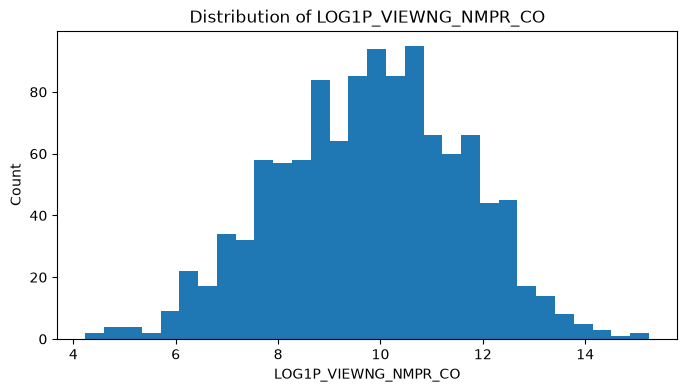

In [5]:
# 목적변수 결측 제거

model_df = df.dropna(subset=[target]).copy()

print(f"원본 데이터: {df.shape[0]:,}행")
print(f"목적변수 결측 제거 후: {model_df.shape[0]:,}행")

# 목적변수 분포 확인
display(model_df[target].describe())

plt.figure(figsize=(8, 4))
plt.hist(model_df[target], bins=30)
plt.title("Distribution of LOG1P_VIEWNG_NMPR_CO")
plt.xlabel("LOG1P_VIEWNG_NMPR_CO")
plt.ylabel("Count")
plt.show()

In [6]:
# 사용할 변수 결측률 확인

all_candidate_features = list(dict.fromkeys(features_staff))

missing_summary = (
    model_df[all_candidate_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_rate"]

display(missing_summary)

,column,missing_rate
0,PRVATE_VLNTER_CO,89.973615
1,CNTRCT_EMP_CO,85.048373
2,PUBLIC_VLNTER_CO,83.905013
3,PRFSN_CO,81.970097
4,GNRL_GVRNM_EMP_CO,74.670185
5,QUALF_HOLD_CO,62.796834
6,ARTGR_EMP_CO,54.265611
7,LOG1P_NMPR_CO,44.327177
8,LOG1P_DATA_CO,43.623571
9,LOG1P_DATA_SPCE_AR_VALUE,42.216359


## 4. Train/Test 분리

모든 변수 세트와 모델이 동일한 train/test 조건에서 비교되도록,  
먼저 공통 인덱스 기준으로 train/test를 나눈다.

시설 유형 비율이 유지되도록 `facility_type` 기준으로 층화 분리한다.

In [7]:
train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=model_df["facility_type"],
)

train_df = model_df.loc[train_idx].copy()
test_df = model_df.loc[test_idx].copy()

print(f"train: {train_df.shape[0]:,}행")
print(f"test : {test_df.shape[0]:,}행")

print("\n시설 유형 비율 - train")
display(train_df["facility_type"].value_counts(normalize=True).round(3))

print("\n시설 유형 비율 - test")
display(test_df["facility_type"].value_counts(normalize=True).round(3))

train: 909행
test : 228행

시설 유형 비율 - train


facility_type
박물관    0.752
미술관    0.248
Name: proportion, dtype: float64


시설 유형 비율 - test


facility_type
박물관    0.754
미술관    0.246
Name: proportion, dtype: float64

## 5. 전처리 파이프라인과 모델 정의

전처리는 수치형 변수와 범주형 변수를 나누어 처리한다.

- 수치형 변수
  - 중앙값 대체
  - 결측 여부 indicator 추가
  - 표준화
- 범주형 변수
  - 최빈값 대체
  - One-Hot Encoding

트리 기반 모델에서는 표준화가 필수는 아니지만, 동일한 파이프라인으로 비교하기 위해 같은 전처리 구조를 사용한다.

In [8]:
def make_onehot_encoder():
    """scikit-learn 버전 차이에 따른 OneHotEncoder 옵션 처리"""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def split_feature_types(data, features):
    """후보 변수 목록을 수치형/범주형으로 분리"""
    numeric_features = [
        col for col in features
        if pd.api.types.is_numeric_dtype(data[col])
    ]
    categorical_features = [
        col for col in features
        if col not in numeric_features
    ]
    return numeric_features, categorical_features


def make_preprocessor(data, features):
    numeric_features, categorical_features = split_feature_types(data, features)

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor, numeric_features, categorical_features


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_log_target(y_true, y_pred):
    """로그 타깃 기준 평가"""
    return {
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": rmse(y_true, y_pred),
        "R2_log": r2_score(y_true, y_pred),
    }


def evaluate_original_scale(y_true_log, y_pred_log):
    """로그 예측값을 원래 관람객 수 단위로 환산한 평가"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)

    return {
        "MAE_original": mean_absolute_error(y_true, y_pred),
        "RMSE_original": rmse(y_true, y_pred),
        "MedianAE_original": median_absolute_error(y_true, y_pred),
    }


models = {
    "Dummy_mean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=3000),
    "RandomForest": RandomForestRegressor(
        n_estimators=30,
        random_state=RANDOM_STATE,
        n_jobs=1,
        min_samples_leaf=2,
        max_depth=8,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=30,
        random_state=RANDOM_STATE,
        n_jobs=1,
        min_samples_leaf=2,
        max_depth=8,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=60,
        learning_rate=0.05,
        max_depth=3,
    ),
}

print("모델 정의 완료")

모델 정의 완료


## 6. 변수 세트별 모델 성능 비교

아래에서는 3개 변수 세트와 여러 모델을 조합해 성능을 비교한다.

- `basic`: 기본 변수 세트
- `extended`: 자료·규모 확장 변수 세트
- `staff`: 인력 변수 포함 실험 변수 세트

평가는 로그 변환 관람객 수 기준으로 수행한다.

In [9]:
results = []
fitted_pipelines = {}

for feature_set_name, features in feature_sets.items():
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    preprocessor, numeric_features, categorical_features = make_preprocessor(train_df, features)

    print(f"\n===== Feature set: {feature_set_name} =====")
    print(f"수치형 변수: {len(numeric_features)}개")
    print(f"범주형 변수: {len(categorical_features)}개")

    for model_name, model_template in models.items():
        # 같은 모델 객체가 여러 변수 세트에서 재사용되지 않도록 매번 복제
        model = clone(model_template)

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model),
            ]
        )

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        log_metrics = evaluate_log_target(y_test, y_pred)
        original_metrics = evaluate_original_scale(y_test, y_pred)

        row = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features_raw": len(features),
            **log_metrics,
            **original_metrics,
        }
        results.append(row)

        fitted_pipelines[(feature_set_name, model_name)] = pipeline

results_df = pd.DataFrame(results)

results_df_sorted = (
    results_df
    .sort_values(["RMSE_log", "MAE_log"], ascending=True)
    .reset_index(drop=True)
)

display(results_df_sorted)


===== Feature set: basic =====
수치형 변수: 5개
범주형 변수: 4개

===== Feature set: extended =====
수치형 변수: 8개
범주형 변수: 4개

===== Feature set: staff =====
수치형 변수: 15개
범주형 변수: 4개


,feature_set,model,n_features_raw,MAE_log,RMSE_log,R2_log,MAE_original,RMSE_original,MedianAE_original
0,staff,Lasso,19,1.053214,1.303292,0.499518,58036.403871,216857.076673,13404.787083
1,staff,GradientBoosting,19,1.030489,1.304268,0.498769,53520.708333,208129.389323,14094.358956
2,staff,Ridge,19,1.054816,1.305130,0.498105,58056.666212,217002.441174,13358.674585
3,staff,RandomForest,19,1.016131,1.306799,0.496821,52937.208604,208619.790969,13055.190284
4,staff,LinearRegression,19,1.057266,1.307362,0.496387,58202.002631,217017.869820,13609.721346
5,extended,ExtraTrees,12,1.067489,1.321724,0.485262,55580.186562,209990.038762,13655.682949
6,extended,Lasso,12,1.074016,1.322647,0.484543,57756.005290,212247.021206,15406.941793
7,extended,Ridge,12,1.075473,1.323733,0.483696,57782.396460,212359.482893,15490.326027
8,extended,LinearRegression,12,1.076903,1.325332,0.482448,57870.581194,212399.925320,15593.730555
9,extended,GradientBoosting,12,1.053378,1.328596,0.479895,54718.119151,208344.495277,14419.948412


In [10]:
# 성능 상위 모델 확인

top_n = 10
display(results_df_sorted.head(top_n))

best_row = results_df_sorted.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_pipeline = fitted_pipelines[(best_feature_set, best_model_name)]

print("Best feature set:", best_feature_set)
print("Best model:", best_model_name)
print("Best RMSE_log:", round(best_row["RMSE_log"], 4))
print("Best R2_log:", round(best_row["R2_log"], 4))

,feature_set,model,n_features_raw,MAE_log,RMSE_log,R2_log,MAE_original,RMSE_original,MedianAE_original
0,staff,Lasso,19,1.053214,1.303292,0.499518,58036.403871,216857.076673,13404.787083
1,staff,GradientBoosting,19,1.030489,1.304268,0.498769,53520.708333,208129.389323,14094.358956
2,staff,Ridge,19,1.054816,1.305130,0.498105,58056.666212,217002.441174,13358.674585
3,staff,RandomForest,19,1.016131,1.306799,0.496821,52937.208604,208619.790969,13055.190284
4,staff,LinearRegression,19,1.057266,1.307362,0.496387,58202.002631,217017.869820,13609.721346
5,extended,ExtraTrees,12,1.067489,1.321724,0.485262,55580.186562,209990.038762,13655.682949
6,extended,Lasso,12,1.074016,1.322647,0.484543,57756.005290,212247.021206,15406.941793
7,extended,Ridge,12,1.075473,1.323733,0.483696,57782.396460,212359.482893,15490.326027
8,extended,LinearRegression,12,1.076903,1.325332,0.482448,57870.581194,212399.925320,15593.730555
9,extended,GradientBoosting,12,1.053378,1.328596,0.479895,54718.119151,208344.495277,14419.948412


Best feature set: staff
Best model: Lasso
Best RMSE_log: 1.3033
Best R2_log: 0.4995


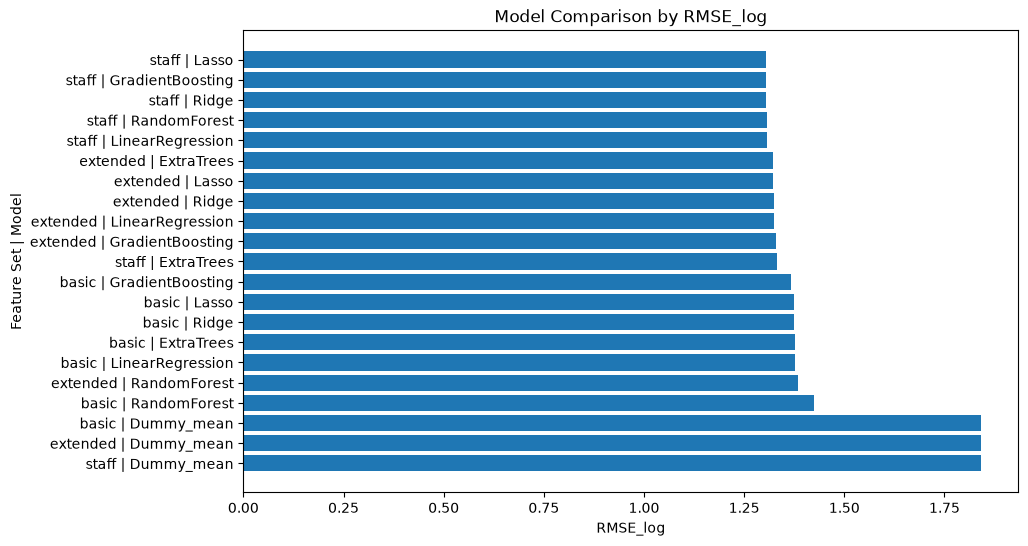

In [11]:
# 모델 성능 시각화: RMSE_log 기준

plot_df = results_df_sorted.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["RMSE_log"])
plt.gca().invert_yaxis()
plt.title("Model Comparison by RMSE_log")
plt.xlabel("RMSE_log")
plt.ylabel("Feature Set | Model")
plt.show()

## 7. 최종 후보 모델 예측 결과 확인

가장 성능이 좋은 모델의 예측값을 확인한다.

해석 편의를 위해 로그 예측값뿐 아니라 원래 관람객 수 단위로 환산한 값도 함께 만든다.

In [12]:
best_features = feature_sets[best_feature_set]

X_test_best = test_df[best_features]
y_test_log = test_df[target]
y_pred_log = best_pipeline.predict(X_test_best)

prediction_df = test_df[
    ["FCLTY_NM", "facility_type", "CTPRVN_NM", "REGION_GROUP", "VIEWNG_NMPR_CO", target]
].copy()

prediction_df["pred_log"] = y_pred_log
prediction_df["actual_viewers"] = np.expm1(prediction_df[target])
prediction_df["pred_viewers"] = np.clip(np.expm1(prediction_df["pred_log"]), 0, None)
prediction_df["error_log"] = prediction_df[target] - prediction_df["pred_log"]
prediction_df["abs_error_log"] = prediction_df["error_log"].abs()
prediction_df["error_viewers"] = prediction_df["actual_viewers"] - prediction_df["pred_viewers"]
prediction_df["abs_error_viewers"] = prediction_df["error_viewers"].abs()

display(prediction_df.head())

,FCLTY_NM,facility_type,CTPRVN_NM,REGION_GROUP,VIEWNG_NMPR_CO,LOG1P_VIEWNG_NMPR_CO,pred_log,actual_viewers,pred_viewers,error_log,abs_error_log,error_viewers,abs_error_viewers
1065,진천군립 생거판화미술관,미술관,충북,충청권,23058.0,10.045811,9.140308,23058.0,9322.638264,0.905503,0.905503,13735.361736,13735.361736
1037,한향림도자미술관,미술관,경기,수도권,7000.0,8.853808,9.226657,7000.0,10163.500574,-0.372848,0.372848,-3163.500574,3163.500574
834,진주교육대학교박물관,박물관,경남,경상권,2201.0,7.697121,8.127743,2201.0,3386.146426,-0.430622,0.430622,-1185.146426,1185.146426
664,한국천연염색박물관,박물관,전남,전라권,113962.0,11.643629,10.544910,113962.0,37982.610774,1.098719,1.098719,75979.389226,75979.389226
35,한성백제박물관,박물관,서울,수도권,511919.0,13.145924,12.713698,511919.0,332267.168788,0.432226,0.432226,179651.831212,179651.831212


In [13]:
# 최종 후보 모델 평가 결과

best_log_metrics = evaluate_log_target(y_test_log, y_pred_log)
best_original_metrics = evaluate_original_scale(y_test_log, y_pred_log)

best_metrics_df = pd.DataFrame([{**best_log_metrics, **best_original_metrics}])

display(best_metrics_df)

,MAE_log,RMSE_log,R2_log,MAE_original,RMSE_original,MedianAE_original
0,1.053214,1.303292,0.499518,58036.403871,216857.076673,13404.787083


In [14]:
# 예측 오차가 큰 시설 확인

error_cols = [
    "FCLTY_NM",
    "facility_type",
    "CTPRVN_NM",
    "REGION_GROUP",
    "actual_viewers",
    "pred_viewers",
    "abs_error_viewers",
    "LOG1P_VIEWNG_NMPR_CO",
    "pred_log",
    "abs_error_log",
]

display(
    prediction_df
    .sort_values("abs_error_log", ascending=False)
    [error_cols]
    .head(15)
)

,FCLTY_NM,facility_type,CTPRVN_NM,REGION_GROUP,actual_viewers,pred_viewers,abs_error_viewers,LOG1P_VIEWNG_NMPR_CO,pred_log,abs_error_log
534,백제군사박물관,박물관,충남,충청권,2917684.0,61580.684247,2.856103e+06,14.886301,11.028120,3.858181
641,목포근대역사관2관,박물관,전남,전라권,226015.0,5885.184063,2.201298e+05,12.328361,8.680363,3.647998
753,경주대학교박물관,박물관,경북,경상권,90.0,2681.260407,2.591260e+03,4.510860,7.894415,3.383556
1034,포마자동차디자인미술관,미술관,경기,수도권,577.0,13459.616870,1.288262e+04,6.359574,9.507523,3.147950
1032,죽포미술관,미술관,경기,수도권,550.0,12653.238045,1.210324e+04,6.311735,9.445747,3.134013
1144,학명미술관,미술관,전남,전라권,711.0,12746.436445,1.203544e+04,6.568078,9.453085,2.885008
509,불교천태중앙박물관,박물관,충북,충청권,100605.0,6586.685640,9.401831e+04,11.518967,8.792957,2.726010
604,신평면 생활사박물관,박물관,전북특별자치도,전라권,200.0,2753.530036,2.553530e+03,5.303305,7.921002,2.617697
1001,C ART MUSEUM,미술관,경기,수도권,1500.0,19474.511755,1.797451e+04,7.313887,9.876913,2.563026
769,고성수석전시관,박물관,경남,경상권,238438.0,18478.816378,2.199592e+05,12.381869,9.824434,2.557434


## 8. 잔차 분석

예측값과 실제값의 관계, 잔차 분포를 확인한다.

잔차 분석은 모델이 특정 구간이나 특정 시설 유형에서 체계적으로 틀리는지 확인하는 데 사용한다.

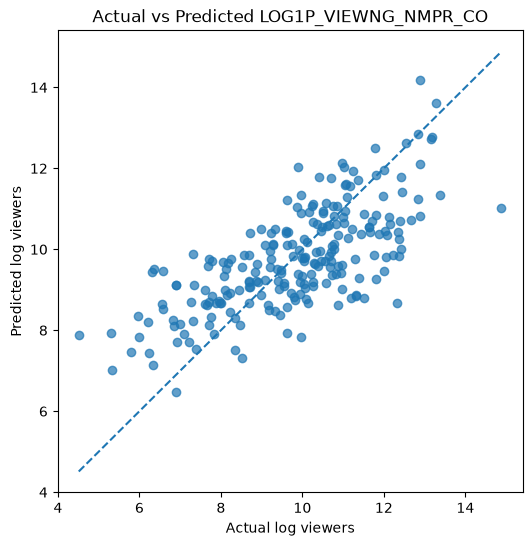

In [15]:
# 실제값 vs 예측값: 로그 기준

plt.figure(figsize=(6, 6))
plt.scatter(y_test_log, y_pred_log, alpha=0.7)
min_value = min(y_test_log.min(), y_pred_log.min())
max_value = max(y_test_log.max(), y_pred_log.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted LOG1P_VIEWNG_NMPR_CO")
plt.xlabel("Actual log viewers")
plt.ylabel("Predicted log viewers")
plt.show()

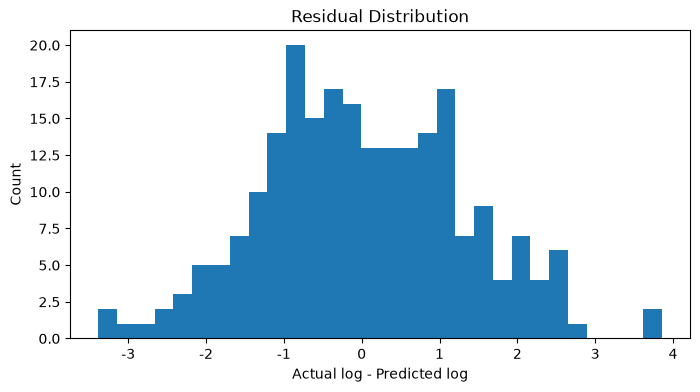

In [16]:
# 잔차 분포

plt.figure(figsize=(8, 4))
plt.hist(prediction_df["error_log"], bins=30)
plt.title("Residual Distribution")
plt.xlabel("Actual log - Predicted log")
plt.ylabel("Count")
plt.show()

In [17]:
# 시설 유형별 잔차 확인

residual_by_type = (
    prediction_df
    .groupby("facility_type")
    .agg(
        n=("FCLTY_NM", "count"),
        mean_error_log=("error_log", "mean"),
        median_abs_error_log=("abs_error_log", "median"),
        mean_abs_error_log=("abs_error_log", "mean"),
        mean_abs_error_viewers=("abs_error_viewers", "mean"),
    )
    .reset_index()
)

display(residual_by_type)

,facility_type,n,mean_error_log,median_abs_error_log,mean_abs_error_log,mean_abs_error_viewers
0,미술관,56,-0.275219,0.879996,1.090315,27715.939378
1,박물관,172,0.122932,0.853464,1.041135,67908.183009


In [18]:
# 지역별 잔차 확인

residual_by_region = (
    prediction_df
    .groupby("CTPRVN_NM")
    .agg(
        n=("FCLTY_NM", "count"),
        mean_error_log=("error_log", "mean"),
        median_abs_error_log=("abs_error_log", "median"),
        mean_abs_error_log=("abs_error_log", "mean"),
        mean_abs_error_viewers=("abs_error_viewers", "mean"),
    )
    .sort_values("mean_abs_error_log", ascending=False)
    .reset_index()
)

display(residual_by_region)

,CTPRVN_NM,n,mean_error_log,median_abs_error_log,mean_abs_error_log,mean_abs_error_viewers
0,전북특별자치도,8,0.845730,1.260587,1.500154,104853.387261
1,경북,16,0.138778,1.114809,1.418996,58113.451295
2,대전,4,-0.638143,1.615179,1.407909,16853.763636
3,강원,2,-0.850112,1.366125,1.366125,8121.702730
4,전남,19,0.049472,1.198123,1.281120,33149.125476
5,부산,8,-0.500751,0.977521,1.154063,22897.389030
6,충북,12,0.825061,0.853859,1.153923,39370.431349
7,충남,13,-0.113065,0.737152,1.099213,241957.314085
8,서울,39,0.252010,1.013566,1.060445,89639.030811
9,전북,5,-0.087282,0.555176,0.991469,13678.996483


## 9. 변수 중요도 분석

최종 후보 모델에 대해 permutation importance를 계산한다.

Permutation importance는 원본 입력 변수 단위로 계산되므로,  
범주형 변수가 원-핫 인코딩으로 여러 개의 더미 변수로 나뉘는 문제를 피할 수 있다.

해석 기준:

- 값이 클수록 해당 변수를 섞었을 때 모델 성능이 더 많이 떨어졌다는 뜻
- 즉, 해당 변수가 예측에 더 중요하게 사용되었을 가능성이 높음
- 단, 변수 간 상관관계가 있으면 중요도가 분산되거나 과소평가될 수 있음

In [19]:
# Permutation Importance 계산

perm = permutation_importance(
    best_pipeline,
    X_test_best,
    y_test_log,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(importance_df)

,feature,importance_mean,importance_std
0,OPNNG_DAY_CO,0.179632,0.015928
1,LOG1P_NMPR_CO,0.114152,0.029874
2,LOG1P_LND_AR_VALUE,0.079117,0.016246
3,ARTGR_EMP_CO,0.057686,0.010276
4,facility_type,0.037667,0.008375
5,LOG1P_TOT_PROGRM_CO,0.036337,0.010242
6,MOBILE_PROVD_AT,0.028743,0.010600
7,LOG1P_EDC_FCLTY_AR_VALUE,0.018536,0.004543
8,PRVATE_VLNTER_CO,0.018409,0.006542
9,LOG1P_DATA_CO,0.018370,0.007726


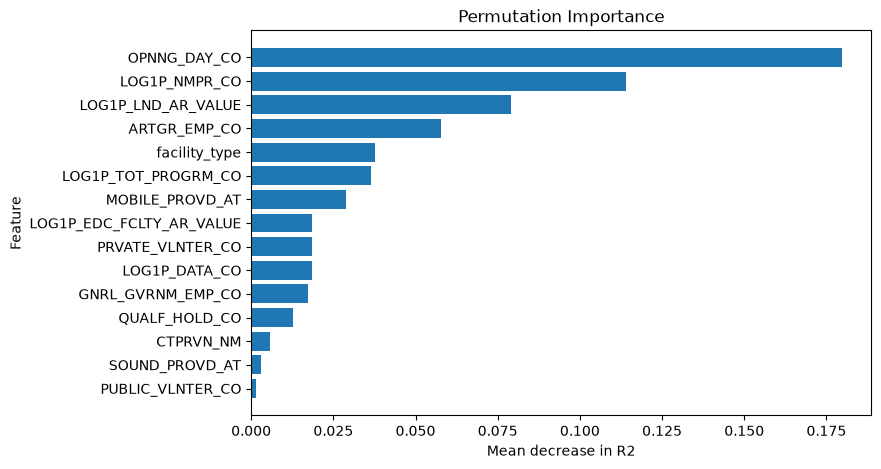

In [20]:
# 변수 중요도 시각화

top_importance = importance_df.head(15).copy()

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance")
plt.xlabel("Mean decrease in R2")
plt.ylabel("Feature")
plt.show()

## 10. 선형 모델 계수 참고 확인

최종 후보가 트리 기반 모델일 수 있으므로, 해석 보조용으로 `basic` 변수 세트의 Ridge 계수도 확인한다.

단, 원-핫 인코딩된 범주형 변수의 계수는 기준 범주와 인코딩 구조에 따라 해석해야 하므로  
절대적인 영향력으로 단정하지 않는다.

In [21]:
# Ridge 모델 계수 확인

# 주의:
# SimpleImputer(add_indicator=True)를 사용하면 결측 여부 indicator 변수가 추가된다.
# scikit-learn 버전에 따라 get_feature_names_out() 결과와 coef_ 길이가 맞지 않을 수 있어
# 길이 불일치 시 feature 이름을 직접 복원한다.

ridge_key = ("basic", "Ridge")

def get_safe_feature_names(preprocessor, coef_length):
    """전처리 후 feature name을 안전하게 추출하는 함수"""
    try:
        feature_names = list(preprocessor.get_feature_names_out())
    except Exception:
        feature_names = []

    # 길이가 맞으면 그대로 사용
    if len(feature_names) == coef_length:
        return feature_names

    # 길이가 맞지 않으면 ColumnTransformer 내부 구조를 이용해 직접 생성
    manual_names = []

    try:
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == "drop":
                continue

            cols = list(cols)

            if name == "num":
                # 원래 수치형 변수명
                manual_names.extend(cols)

                # SimpleImputer(add_indicator=True)로 추가된 결측 indicator 변수명
                imputer = transformer.named_steps.get("imputer")
                if hasattr(imputer, "indicator_") and imputer.indicator_ is not None:
                    missing_idx = getattr(imputer.indicator_, "features_", [])
                    manual_names.extend([f"{cols[i]}_missing" for i in missing_idx])

            elif name == "cat":
                # 범주형 원-핫 인코딩 변수명
                try:
                    onehot = transformer.named_steps["onehot"]
                    manual_names.extend(list(onehot.get_feature_names_out(cols)))
                except Exception:
                    manual_names.extend(cols)

        if len(manual_names) == coef_length:
            return manual_names

    except Exception as e:
        print("feature name 직접 복원 실패:", e)

    # 그래도 길이가 맞지 않으면 임시 이름 사용
    print("feature 이름 개수와 계수 개수가 맞지 않아 임시 이름을 사용합니다.")
    print(f"feature_names: {len(feature_names)}, manual_names: {len(manual_names)}, coef: {coef_length}")
    return [f"feature_{i}" for i in range(coef_length)]


if ridge_key in fitted_pipelines:
    ridge_pipeline = fitted_pipelines[ridge_key]
    ridge_model = ridge_pipeline.named_steps["model"]
    preprocessor = ridge_pipeline.named_steps["preprocessor"]

    ridge_coef = np.ravel(ridge_model.coef_)
    feature_names = get_safe_feature_names(preprocessor, len(ridge_coef))

    coef_df = (
        pd.DataFrame({
            "feature": feature_names,
            "coef": ridge_coef,
            "abs_coef": np.abs(ridge_coef),
        })
        .sort_values("abs_coef", ascending=False)
        .reset_index(drop=True)
    )

    display(coef_df.head(30))
else:
    print("basic Ridge 모델을 찾지 못했습니다.")

,feature,coef,abs_coef
0,OPNNG_DAY_CO,0.621939,0.621939
1,CTPRVN_NM_제주특별자치도,0.589760,0.589760
2,CTPRVN_NM_울산,0.530272,0.530272
3,CTPRVN_NM_제주,0.522805,0.522805
4,CTPRVN_NM_세종특별자치시,-0.517142,0.517142
5,CTPRVN_NM_충북,-0.498296,0.498296
6,LOG1P_LND_AR_VALUE,0.477871,0.477871
7,SOUND_PROVD_AT_X,-0.464980,0.464980
8,SOUND_PROVD_AT_전시별 상이,0.370033,0.370033
9,MOBILE_PROVD_AT_X,-0.321362,0.321362


## 11. 모델 성능 해석용 요약 생성

아래 셀은 실행 결과를 바탕으로 보고서/발표에 넣을 수 있는 요약 문장을 자동 생성한다.  
문장은 그대로 사용하기보다, 최종 결과를 확인한 뒤 자연스럽게 다듬어 사용한다.

In [22]:
# 결과 요약 문장 자동 생성

top_features = importance_df.head(5)["feature"].tolist()

summary_text = f"""
## 머신러닝 모델링 결과 요약 초안

본 노트북에서는 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)를 목적변수로 설정하고,
기본 변수 세트, 자료·규모 확장 변수 세트, 인력 변수 포함 변수 세트를 비교하였다.

성능 비교 결과, 테스트 데이터 기준 가장 우수한 조합은 `{best_feature_set}` 변수 세트와 `{best_model_name}` 모델이었다.
해당 모델의 로그 기준 RMSE는 {best_log_metrics['RMSE_log']:.3f}, MAE는 {best_log_metrics['MAE_log']:.3f}, R²는 {best_log_metrics['R2_log']:.3f}로 나타났다.

평균 예측 모델 대비 실제 운영·시설 변수를 사용한 모델의 성능이 개선되어,
문화시설의 관람객 수는 지역, 시설 규모, 운영 특성, 프로그램 및 서비스 제공 변수 등을 통해 일정 부분 예측 가능하다는 점을 확인하였다.

Permutation importance 기준 상위 변수는 {', '.join(top_features)} 등으로 나타났다.
이는 EDA와 통계분석에서 확인한 시설 규모, 지역, 운영 특성 등이 머신러닝 예측에서도 중요한 변수로 작용했을 가능성을 보여준다.

다만 본 모델은 관람객 수 기반 파생 변수와 관람객 수 기반 이상치 플래그를 제외하여 데이터 누수를 방지했으며,
인력 변수와 일부 시설 규모 변수는 결측률이 높기 때문에 결과 해석 시 주의가 필요하다.
"""

print(summary_text)


## 머신러닝 모델링 결과 요약 초안

본 노트북에서는 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)를 목적변수로 설정하고,
기본 변수 세트, 자료·규모 확장 변수 세트, 인력 변수 포함 변수 세트를 비교하였다.

성능 비교 결과, 테스트 데이터 기준 가장 우수한 조합은 `staff` 변수 세트와 `Lasso` 모델이었다.
해당 모델의 로그 기준 RMSE는 1.303, MAE는 1.053, R²는 0.500로 나타났다.

평균 예측 모델 대비 실제 운영·시설 변수를 사용한 모델의 성능이 개선되어,
문화시설의 관람객 수는 지역, 시설 규모, 운영 특성, 프로그램 및 서비스 제공 변수 등을 통해 일정 부분 예측 가능하다는 점을 확인하였다.

Permutation importance 기준 상위 변수는 OPNNG_DAY_CO, LOG1P_NMPR_CO, LOG1P_LND_AR_VALUE, ARTGR_EMP_CO, facility_type 등으로 나타났다.
이는 EDA와 통계분석에서 확인한 시설 규모, 지역, 운영 특성 등이 머신러닝 예측에서도 중요한 변수로 작용했을 가능성을 보여준다.

다만 본 모델은 관람객 수 기반 파생 변수와 관람객 수 기반 이상치 플래그를 제외하여 데이터 누수를 방지했으며,
인력 변수와 일부 시설 규모 변수는 결측률이 높기 때문에 결과 해석 시 주의가 필요하다.



## 12. 결과 저장

모델링 결과를 CSV로 저장한다.

저장 경로:

```text
outputs/ml/
```

저장 파일:

- `model_performance.csv`
- `best_model_predictions.csv`
- `best_model_permutation_importance.csv`
- `residual_by_facility_type.csv`
- `residual_by_region.csv`

In [23]:
SAVE_OUTPUT = True

if SAVE_OUTPUT:
    output_dir = "outputs/ml"
    os.makedirs(output_dir, exist_ok=True)

    results_df_sorted.to_csv(
        os.path.join(output_dir, "model_performance.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    prediction_df.to_csv(
        os.path.join(output_dir, "best_model_predictions.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    importance_df.to_csv(
        os.path.join(output_dir, "best_model_permutation_importance.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    residual_by_type.to_csv(
        os.path.join(output_dir, "residual_by_facility_type.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    residual_by_region.to_csv(
        os.path.join(output_dir, "residual_by_region.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    print(f"결과 저장 완료: {output_dir}")
else:
    print("SAVE_OUTPUT = False 이므로 결과를 저장하지 않았습니다.")

결과 저장 완료: outputs/ml


## 13. 최종 정리

이번 노트북에서는 통계분석에서 확인한 주요 변수들을 바탕으로 관람객 수 예측 모델을 구성하였다.

정리할 때는 아래 내용을 중심으로 작성하면 된다.

1. 목적변수는 `LOG1P_VIEWNG_NMPR_CO`로 설정하였다.
2. 관람객 수 기반 파생 변수와 이상치 플래그는 데이터 누수 방지를 위해 제외하였다.
3. 기본 변수 세트, 자료·규모 확장 변수 세트, 인력 포함 변수 세트를 비교하였다.
4. 평균 예측 모델 대비 실제 변수를 사용한 모델이 성능 개선을 보였는지 확인하였다.
5. 최종 후보 모델의 변수 중요도를 통해 관람객 수 예측에 기여한 요인을 해석하였다.
6. 인력 변수는 결측률이 높으므로, 최종 결론에서는 보조적 해석으로 제한하는 것이 적절하다.

다음 단계에서는 머신러닝 결과를 바탕으로 EDA, 통계분석, 모델링 결과를 종합하여  
문화시설 활성화와 관련된 핵심 요인 및 대시보드 구성 방향을 정리한다.